# Segmentación de Clientes con Modelo RFM y Clustering en R
## Objetivo:

Realizar una segmentación de clientes utilizando el análisis RFM (Recencia, Frecuencia, Valor Monetario) y el algoritmo de clustering K-Means para identificar distintos perfiles de clientes.
Dataset: Online Retail Dataset del Repositorio de UCI.


## Configuración: Cargando Librerías

Primero, cargamos todos los paquetes que necesitaremos para el análisis. readxl es para leer el archivo de Excel original, y factoextra nos ayudará a visualizar los resultados del clustering.

In [1]:
# Pacman es un excelente gestor de paquetes para R. Instalará y cargará paquetes en un solo comando.
# Si no tienes pacman, ejecuta:
install.packages("pacman")
pacman::p_load(
  tidyverse,    # Para manipulación de datos y gráficos con ggplot2
  readxl,       # Para leer archivos de Excel (.xlsx)
  lubridate,    # Para facilitar el manejo de fechas
  cluster,      # Contiene algoritmos de clustering
  factoextra    # Para visualizar y evaluar resultados de clustering
)

# Establecemos un tema visual consistente para todos nuestros gráficos
theme_set(theme_minimal())

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘remotes’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’



factoextra installed



## Carga y Limpieza de Datos

El éxito de cualquier análisis depende de la calidad de los datos. El conjunto de datos "Online Retail" requiere una limpieza significativa antes de poder usarlo.

In [2]:
# Descargar el archivo de datos directamente desde el repositorio de UCI
url <- "http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
download.file(url, destfile = "OnlineRetail.xlsx", mode = "wb")

# Leer el archivo de Excel
retail_raw <- read_excel("OnlineRetail.xlsx")

head(retail_raw)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


### Pasos de Limpieza:

    Eliminar transacciones con CustomerID faltante, ya que no podemos asignarlas a un cliente.
    Eliminar transacciones con cantidad (Quantity) negativa, que representan devoluciones o cancelaciones.
    Eliminar transacciones con precio (Price) igual a cero.
    Asegurarnos de que las columnas tengan el tipo de dato correcto.

In [3]:
# --- Proceso de Limpieza de Datos ---
retail_clean <- retail_raw %>%
  # Eliminar filas donde CustomerID es NA
  drop_na(CustomerID) %>%
  # Filtrar devoluciones (Quantity > 0) y precios válidos (Price > 0)
  filter(Quantity > 0, UnitPrice > 0) %>%
  # Convertir la columna de fecha a un formato de fecha adecuado
  mutate(InvoiceDate = as.Date(InvoiceDate))

# Verificamos la estructura y las primeras filas de nuestros datos limpios
glimpse(retail_clean)
head(retail_clean)

Rows: 397,884
Columns: 8
$ InvoiceNo   <chr> "536365", "536365", "536365", "536365", "536365", "536365"…
$ StockCode   <chr> "85123A", "71053", "84406B", "84029G", "84029E", "22752", …
$ Description <chr> "WHITE HANGING HEART T-LIGHT HOLDER", "WHITE METAL LANTERN…
$ Quantity    <dbl> 6, 6, 8, 6, 6, 2, 6, 6, 6, 32, 6, 6, 8, 6, 6, 3, 2, 3, 3, …
$ InvoiceDate <date> 2010-12-01, 2010-12-01, 2010-12-01, 2010-12-01, 2010-12-0…
$ UnitPrice   <dbl> 2.55, 3.39, 2.75, 3.39, 3.39, 7.65, 4.25, 1.85, 1.85, 1.69…
$ CustomerID  <dbl> 17850, 17850, 17850, 17850, 17850, 17850, 17850, 17850, 17…
$ Country     <chr> "United Kingdom", "United Kingdom", "United Kingdom", "Uni…


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<date>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01,7.65,17850,United Kingdom


## Cálculo de las Métricas RFM

Ahora, calcularemos los tres pilares del modelo RFM para cada cliente:

    Recencia (Recency): ¿Cuán recientemente ha comprado el cliente? (Menor valor = mejor)
    Frecuencia (Frequency): ¿Con qué frecuencia compra el cliente? (Mayor valor = mejor)
    Valor Monetario (Monetary): ¿Cuánto dinero gasta el cliente? (Mayor valor = mejor)

In [4]:
# Calculamos el valor total por transacción
retail <- retail_clean %>%
  mutate(TotalPurchase = Quantity * UnitPrice)

# Fijamos una "fecha de referencia" para calcular la recencia.
# Usamos el día siguiente a la última transacción en el dataset.
snapshot_date <- max(retail$InvoiceDate) + 1

# Calculamos los valores RFM para cada cliente
rfm_data <- retail %>%
  group_by(CustomerID) %>%
  summarise(
    Recency = as.numeric(snapshot_date - max(InvoiceDate)),
    Frequency = n_distinct(InvoiceNo), # Contamos el número de facturas únicas
    Monetary = sum(TotalPurchase)
  )

# Inspeccionamos el resultado
head(rfm_data)
summary(rfm_data)

CustomerID,Recency,Frequency,Monetary
<dbl>,<dbl>,<int>,<dbl>
12346,326,1,77183.60
12347,3,7,4310.00
12348,76,4,1797.24
12349,19,1,1757.55
12350,311,1,334.40
12352,37,8,2506.04


   CustomerID       Recency         Frequency          Monetary        
 Min.   :12346   Min.   :  1.00   Min.   :  1.000   Min.   :     3.75  
 1st Qu.:13813   1st Qu.: 18.00   1st Qu.:  1.000   1st Qu.:   307.42  
 Median :15300   Median : 51.00   Median :  2.000   Median :   674.49  
 Mean   :15300   Mean   : 93.06   Mean   :  4.272   Mean   :  2054.27  
 3rd Qu.:16779   3rd Qu.:142.75   3rd Qu.:  5.000   3rd Qu.:  1661.74  
 Max.   :18287   Max.   :374.00   Max.   :209.000   Max.   :280206.02  

## Preparación de Datos para Clustering

Los algoritmos basados en distancia como K-Means son sensibles a la escala y distribución de las variables.

    Visualización: Veremos que las variables RFM están muy sesgadas (asimétricas).
    Transformación Logarítmica: Aplicaremos un logaritmo para reducir la asimetría y el efecto de los valores extremos.
    Escalado: Estandarizaremos los datos para que todas las variables tengan media 0 y desviación estándar 1, asegurando que todas contribuyan por igual al cálculo de la distancia.

    Recency           Frequency          Monetary       
 Min.   :-2.42073   Min.   :-0.9551   Min.   :-4.00411  
 1st Qu.:-0.69833   1st Qu.:-0.9551   1st Qu.:-0.68559  
 Median : 0.07196   Median :-0.3615   Median :-0.06218  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.00000  
 3rd Qu.: 0.84991   3rd Qu.: 0.6532   3rd Qu.: 0.65411  
 Max.   : 1.58350   Max.   : 5.8579   Max.   : 4.73105  

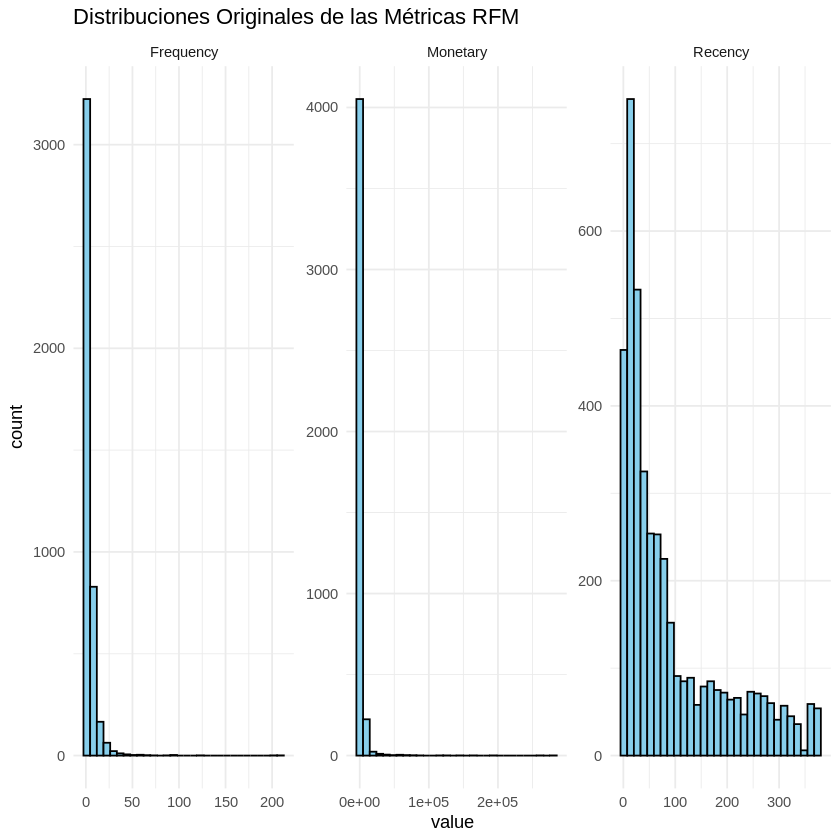

In [5]:
# 1. Visualizamos la distribución original de las variables RFM
rfm_data %>%
  select(Recency, Frequency, Monetary) %>%
  gather(key = "metric", value = "value") %>%
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = "skyblue", color = "black") +
  facet_wrap(~metric, scales = "free") +
  labs(title = "Distribuciones Originales de las Métricas RFM")

# 2. Aplicamos transformación logarítmica (log1p para manejar posibles ceros)
rfm_log <- rfm_data %>%
  mutate(
    Recency = log1p(Recency),
    Frequency = log1p(Frequency),
    Monetary = log1p(Monetary)
  )

# 3. Escalamos los datos transformados
rfm_scaled <- rfm_log %>%
  select(-CustomerID) %>%
  scale() %>%
  as.data.frame()

# Verificamos el resultado del escalado
summary(rfm_scaled)

## Determinación del Número Óptimo de Clústeres (k)

En lugar de adivinar, usaremos el "Método del Codo" (Elbow Method) para encontrar un valor de k apropiado. Buscamos el "codo" en el gráfico, que representa el punto donde añadir más clústeres ya no mejora significativamente la varianza total dentro de los clústeres.

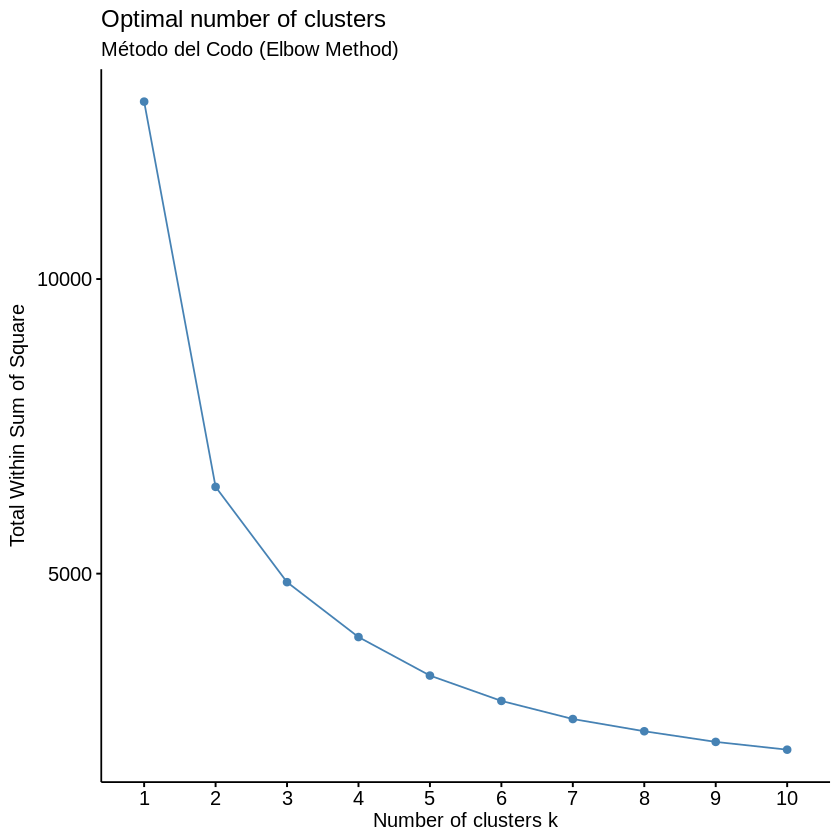

In [6]:
# Usamos fviz_nbclust para calcular y graficar el método del codo
set.seed(123) # Para reproducibilidad
fviz_nbclust(rfm_scaled, kmeans, method = "wss") +
  labs(subtitle = "Método del Codo (Elbow Method)")

Interpretación: El gráfico muestra un "codo" claro alrededor de k=3 o k=4. Esto sugiere que segmentar a los clientes en 3 o 4 grupos es una opción razonable. Para este ejemplo, elegiremos k = 3.

## Aplicación del Algoritmo K-Means

Ahora que hemos elegido k=3, aplicamos el algoritmo K-Means a nuestros datos escalados.

In [7]:
# Ejecutamos K-Means con k=3
set.seed(123)
km_result <- kmeans(rfm_scaled, centers = 3, nstart = 25)

# Agregamos la asignación de clústeres a nuestro data frame original (no escalado)
# Esto es crucial para poder interpretar los resultados en sus unidades originales.
rfm_data_clustered <- rfm_data %>%
  mutate(Cluster = km_result$cluster)

head(rfm_data_clustered)

CustomerID,Recency,Frequency,Monetary,Cluster
<dbl>,<dbl>,<int>,<dbl>,<int>
12346,326,1,77183.60,2
12347,3,7,4310.00,3
12348,76,4,1797.24,2
12349,19,1,1757.55,2
12350,311,1,334.40,1
12352,37,8,2506.04,3


## Análisis e Interpretación de los Clústeres

Este es el paso más importante: entender qué significa cada clúster en términos de negocio. Calcularemos los promedios de R, F y M para cada grupo y los visualizaremos.

# A tibble: 3 × 5
  Cluster Recency_Prom Frecuencia_Prom Monetario_Prom Num_Clientes
    <int>        <dbl>           <dbl>          <dbl>        <int>
1       3         17.8           13.4           7978.          762
2       2         43.7            3.37          1263.         1701
3       1        168.             1.36           365.         1875


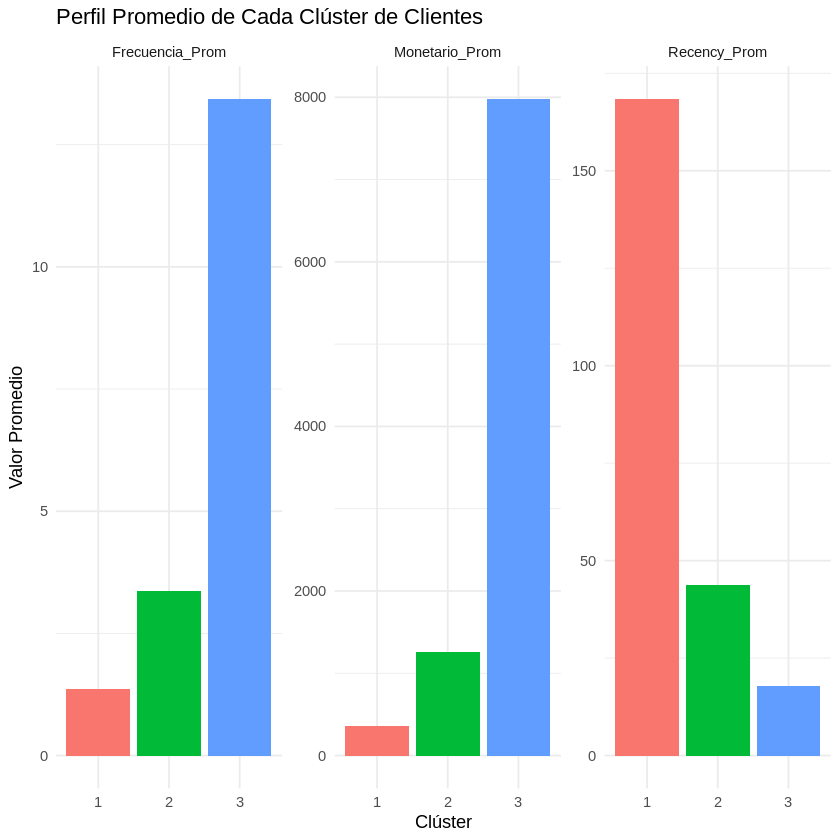

In [8]:
# Calculamos los promedios de RFM y el tamaño de cada clúster
cluster_summary <- rfm_data_clustered %>%
  group_by(Cluster) %>%
  summarise(
    Recency_Prom = mean(Recency),
    Frecuencia_Prom = mean(Frequency),
    Monetario_Prom = mean(Monetary),
    Num_Clientes = n()
  ) %>%
  arrange(Recency_Prom) # Ordenamos para facilitar la interpretación

print(cluster_summary)

# --- Visualización de las Características del Clúster ---
cluster_summary %>%
  select(-Num_Clientes) %>%
  gather(key = "metric", value = "value", -Cluster) %>%
  ggplot(aes(x = as.factor(Cluster), y = value, fill = as.factor(Cluster))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~metric, scales = "free_y") +
  labs(
    title = "Perfil Promedio de Cada Clúster de Clientes",
    x = "Clúster",
    y = "Valor Promedio"
  )

## Interpretación de los Clústeres (basado en un resultado típico):

**El orden de los clusters puede variar**

**Clúster 1 (Clientes Campeones/Leales)**:
* Recencia más baja: Han comprado muy recientemente.
* Frecuencia más alta: Compran a menudo.
* Valor Monetario más alto: Gastan la mayor cantidad de dinero.
* Acción de Negocio: Estos son tus mejores clientes. Hay que retenerlos con programas de lealtad, acceso anticipado a productos y un servicio premium.

**Clúster 2 (Clientes en Riesgo/Necesitan Atención):**
* Recencia media/alta: Ha pasado un tiempo considerable desde su última compra.
* Frecuencia y Valor Monetario medios: Solían ser buenos clientes, pero están "durmiendo".
* Acción de Negocio: Lanzar campañas de reactivación con ofertas especiales o descuentos para incentivar una nueva compra.

**Clúster 3 (Clientes Ocasionales/Nuevos):**
* Recencia alta: Su última compra fue hace mucho tiempo (o son nuevos y solo han comprado una vez).
* Frecuencia y Valor Monetario más bajos: Compran esporádicamente y gastan poco.
* Acción de Negocio: Pueden ser clientes nuevos o de bajo valor. Se pueden incluir en campañas de marketing generales para aumentar su frecuencia de compra y convertirlos en clientes más leales.